# Аудит данных для дальнего прогноза без погоды

После первых запусков сервиса стало понятно, что одну общую модель для всех дат делать неправильно.

У сервиса есть две разные ситуации:

- **Ближайшие даты, примерно 14 дней вперед.** Здесь есть прогноз погоды, табло аэропорта и расписание. Эту часть сейчас не трогаем: понятные правила уже дают хорошее качество и лучше подходят для живого сервиса.
- **Даты дальше погодного горизонта.** Здесь подробной погоды уже нет. Остается календарь и накопленная история вылетов/отмен. Именно эту климатико-историческую оценку и будем улучшать.

Цель этого ноутбука — собрать и проверить честную таблицу для дальнего прогноза: без видимости, ветра, давления, облачности и других погодных признаков.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import warnings

from IPython import get_ipython
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("png")
except Exception:
    pass

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

BUILD_SCRIPT = PROJECT_ROOT / "pipelines" / "training" / "build_historical_only_dataset.py"
TARGET_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_daily_flights_historical_only.csv"
DATASET_PATH = PROJECT_ROOT / "data" / "processed" / "historical_only_dataset.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "interim" / "training" / "historical_only_feature_sets.json"
SUMMARY_PATH = PROJECT_ROOT / "data" / "interim" / "training" / "historical_only_dataset_summary.txt"

print("project_root:", PROJECT_ROOT)
print("build_script:", BUILD_SCRIPT)

project_root: /work
build_script: /work/pipelines/training/build_historical_only_dataset.py


## Сбор таблицы

Новые факты берем из папки `backup`, но только финальные строки до `2026-06-13` включительно. День `2026-06-14` не берем: в старом бэкапе для него могли быть статусы, полученные до исправления логики табло.

In [2]:
subprocess.run([sys.executable, str(BUILD_SCRIPT)], cwd=PROJECT_ROOT, check=True)
print(SUMMARY_PATH.read_text(encoding="utf-8"))

Max backup target date: 2026-06-13
Target dataset: data/processed/dataset_daily_flights_historical_only.csv (779 rows)
Historical-only dataset: data/processed/historical_only_dataset.csv (779 rows)
Summary: data/interim/training/historical_only_dataset_summary.txt
Feature sets: data/interim/training/historical_only_feature_sets.json
data_version=historical-only-2026-06-14
target_data_version=telegram-v2-plus-historical-board-manual-v4-historical-only-2026-06-14
max_backup_target_date=2026-06-13

base_target_rows=761
augmented_target_rows=779
new_target_rows=18
new_target_date_min=2026-05-27
new_target_date_max=2026-06-13
new_target_status_counts={'cancelled': 4, 'completed': 14}

historical_dataset_rows=779
historical_dataset_date_min=2017-12-13
historical_dataset_date_max=2026-06-13
train_rows=545
train_completed_rate=0.6477
valid_rows=117
valid_completed_rate=0.265
test_rows=117
test_completed_rate=0.3504



## Что получилось

Проверяем размер таблицы, даты, разбиение на периоды и отсутствие погодных колонок.

In [3]:
df = pd.read_csv(DATASET_PATH, parse_dates=["date"])
target_df = pd.read_csv(TARGET_PATH, parse_dates=["date"])
with FEATURES_PATH.open("r", encoding="utf-8") as file:
    feature_sets = json.load(file)

weather_markers = [
    "mendeleyevo", "khomutovo", "weather", "wind_speed", "wind_gust", "wind_direction",
    "cloud_cover", "visibility", "pressure", "humidity", "temperature", "dew_point",
    "fog", "precipitation",
]
weather_columns = [
    column for column in df.columns
    if any(marker in column.lower() for marker in weather_markers)
]

print(f"Строк: {len(df):,}")
print(f"Колонок: {df.shape[1]:,}")
print(f"Период: {df['date'].min().date()} .. {df['date'].max().date()}")
print("Погодные колонки:", weather_columns)
assert not weather_columns, "В таблицу попали погодные признаки, а для этой задачи они запрещены."

display(df.head())
display(df.tail())

Строк: 779
Колонок: 39
Период: 2017-12-13 .. 2026-06-13
Погодные колонки: []


,date,is_flight_completed,dataset_split,month,day,day_of_year,month_decade,season,day_of_week,is_weekend,...,completed_streak_before,history_similar_days_count,history_completed_count,history_cancelled_count,history_probability_flight,history_month_probability_flight,history_decade_probability_flight,history_combined_probability,current_history_decision_45,data_version
0,2017-12-13,0,train,12,13,347,2,winter,2,0,...,0,0,0,0,0.500000,NaN,NaN,0.500000,1,historical-only-2026-06-14
1,2017-12-26,0,train,12,26,360,3,winter,1,0,...,0,1,0,1,0.333333,0.333333,NaN,0.333333,0,historical-only-2026-06-14
2,2018-01-10,0,train,1,10,10,1,winter,2,0,...,0,0,0,0,0.500000,NaN,NaN,0.500000,1,historical-only-2026-06-14
3,2018-01-11,0,train,1,11,11,2,winter,3,0,...,0,1,0,1,0.333333,0.333333,NaN,0.333333,0,historical-only-2026-06-14
4,2018-01-23,0,train,1,23,23,3,winter,1,0,...,0,2,0,2,0.250000,0.250000,NaN,0.250000,0,historical-only-2026-06-14


,date,is_flight_completed,dataset_split,month,day,day_of_year,month_decade,season,day_of_week,is_weekend,...,completed_streak_before,history_similar_days_count,history_completed_count,history_cancelled_count,history_probability_flight,history_month_probability_flight,history_decade_probability_flight,history_combined_probability,current_history_decision_45,data_version
774,2026-06-09,0,test,6,9,160,1,summer,1,0,...,0,97,60,37,0.616162,0.602041,0.558140,0.595854,1,historical-only-2026-06-14
775,2026-06-10,1,test,6,10,161,1,summer,2,0,...,0,94,59,35,0.625000,0.595960,0.545455,0.597159,1,historical-only-2026-06-14
776,2026-06-11,1,test,6,11,162,2,summer,3,0,...,1,95,60,35,0.628866,0.600000,0.516129,0.589408,1,historical-only-2026-06-14
777,2026-06-12,1,test,6,12,163,2,summer,4,0,...,2,97,60,37,0.616162,0.603960,0.531250,0.586443,1,historical-only-2026-06-14
778,2026-06-13,1,test,6,13,164,2,summer,5,1,...,3,96,58,38,0.602041,0.607843,0.545455,0.582236,1,historical-only-2026-06-14


## Новые дни из бэкапа

Проверяем, какие дни были добавлены после старой исторической базы.

In [4]:
new_rows = target_df[target_df["event_date_sources"] == "forecast_monitor_board_outcomes"].copy()
display(new_rows[["date", "status", "is_flight_completed", "reason_class", "message_count"]])

display(
    new_rows.groupby("status")
    .agg(days=("date", "size"), first_date=("date", "min"), last_date=("date", "max"))
)

,date,status,is_flight_completed,reason_class,message_count
761,2026-05-27,cancelled,0,schedule_moved_next_day,134
762,2026-05-28,completed,1,unknown;unknown_delay_reason,92
763,2026-05-29,completed,1,unknown;unknown_delay_reason,86
764,2026-05-30,completed,1,unknown,86
765,2026-05-31,completed,1,unknown,92
766,2026-06-01,completed,1,unknown,92
767,2026-06-02,completed,1,unknown,92
768,2026-06-03,completed,1,unknown,94
769,2026-06-04,completed,1,unknown,92
770,2026-06-05,completed,1,unknown;unknown_delay_reason,180


,days,first_date,last_date
status,,,
cancelled,4,2026-05-27,2026-06-09
completed,14,2026-05-28,2026-06-13


## Баланс вылетов и отмен

Здесь важно смотреть не только общую долю вылетов, но и то, как она меняется между периодами. Если периоды сильно отличаются, случайное перемешивание строк даст слишком красивую, но нечестную оценку.

,rows,completed_rate,first_date,last_date
dataset_split,,,,
train,545,0.6477,2017-12-13,2022-08-26
valid,117,0.2650,2022-08-28,2024-03-29
test,117,0.3504,2024-04-01,2026-06-13


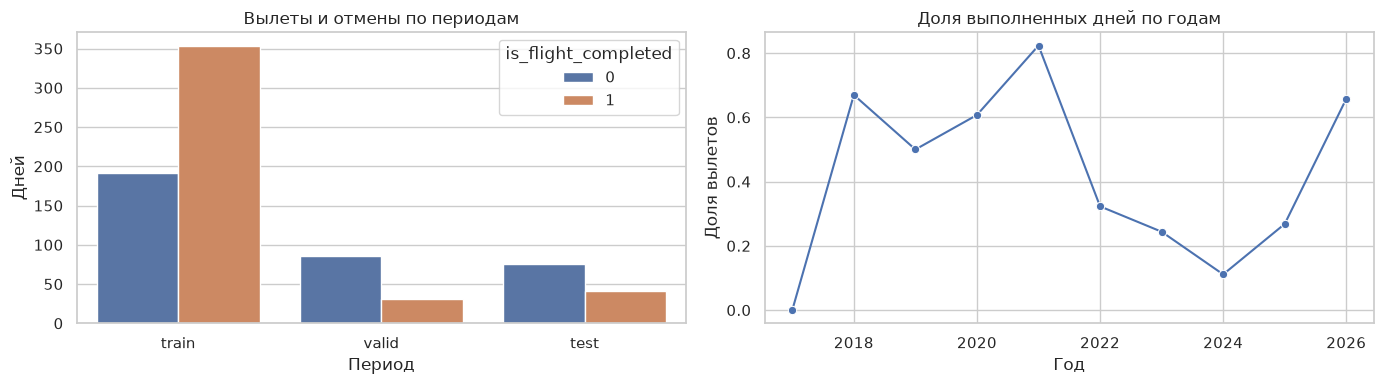

In [5]:
split_summary = (
    df.groupby("dataset_split", sort=False)
    .agg(
        rows=("is_flight_completed", "size"),
        completed_rate=("is_flight_completed", "mean"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .assign(completed_rate=lambda table: table["completed_rate"].round(4))
)
display(split_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=df, x="dataset_split", hue="is_flight_completed", ax=axes[0])
axes[0].set_title("Вылеты и отмены по периодам")
axes[0].set_xlabel("Период")
axes[0].set_ylabel("Дней")

by_year = df.assign(year=df["date"].dt.year).groupby("year").agg(completed_rate=("is_flight_completed", "mean"), rows=("date", "size")).reset_index()
sns.lineplot(data=by_year, x="year", y="completed_rate", marker="o", ax=axes[1])
axes[1].set_title("Доля выполненных дней по годам")
axes[1].set_xlabel("Год")
axes[1].set_ylabel("Доля вылетов")
plt.tight_layout()
plt.show()

## Какие признаки оставляем

Для исторической проверки дальней модели оставляем календарные признаки и признаки, построенные из прошлых наблюдений внутри исторического ряда. Погодные и постфактум-признаки не используем.

В таблицу входят:

- календарь: месяц, день, сезон, день недели;
- циклические признаки даты, чтобы январь и декабрь были рядом;
- недавняя история внутри исторического ряда: были ли отмены в предыдущие дни;
- сезонная история: как часто летали в похожие даты, месяц и декаду месяца;
- текущая климатико-историческая вероятность, которую уже считает сервис.

Не используем источник данных, текст причины отмены, количество сообщений и статус рейса как признаки: это описание факта, а не вход для будущего прогноза.

In [6]:
model_features = feature_sets["historical_model_features"]
feature_groups = {
    "Календарь": [column for column in model_features if column in {"month", "day", "day_of_year", "month_decade", "season", "day_of_week", "is_weekend", "day_of_year_sin", "day_of_year_cos", "month_sin", "month_cos"}],
    "Недавняя история": [column for column in model_features if column.startswith("prev_") or column in {"days_since_last_cancelled", "cancelled_streak_before", "completed_streak_before"}],
    "Похожие даты": [column for column in model_features if column.startswith("same_") or column.startswith("history_")],
}

for group_name, columns in feature_groups.items():
    display(Markdown(f"**{group_name}:** {len(columns)} признаков"))
    display(pd.DataFrame({"column": columns}))

missing = df[model_features].isna().mean().sort_values(ascending=False).reset_index()
missing.columns = ["Признак", "Доля пропусков"]
display(missing.head(15))

**Календарь:** 11 признаков

,column
0,month
1,day
2,day_of_year
3,month_decade
4,season
5,day_of_week
6,is_weekend
7,day_of_year_sin
8,day_of_year_cos
9,month_sin


**Недавняя история:** 10 признаков

,column
0,prev_1_completed
1,prev_3_cancelled_count
2,prev_7_cancelled_count
3,prev_14_completed_rate
4,prev_30_completed_rate
5,prev_60_completed_rate
6,prev_90_completed_rate
7,days_since_last_cancelled
8,cancelled_streak_before
9,completed_streak_before


**Похожие даты:** 13 признаков

,column
0,same_month_past_count
1,same_month_past_completed_rate
2,same_decade_past_count
3,same_decade_past_completed_rate
4,same_doy_window_14_past_count
5,same_doy_window_14_completed_rate
6,history_similar_days_count
7,history_completed_count
8,history_cancelled_count
9,history_probability_flight


,Признак,Доля пропусков
0,same_decade_past_completed_rate,0.055199
1,history_decade_probability_flight,0.055199
2,same_month_past_completed_rate,0.015404
3,history_month_probability_flight,0.015404
4,prev_90_completed_rate,0.012837
5,prev_60_completed_rate,0.012837
6,prev_30_completed_rate,0.006418
7,same_doy_window_14_completed_rate,0.005135
8,prev_14_completed_rate,0.003851
9,prev_7_cancelled_count,0.001284


## Доступность признаков на момент прогноза

В этой таблице исторические признаки считаются последовательно: для каждой даты используются только строки, которые стоят раньше нее в историческом ряду. Поэтому внутри исторической проверки нет подглядывания в сам факт целевого дня.

Но для реального дальнего прогноза есть дополнительное ограничение. Если пользователь сегодня выбирает дату через 30-60 дней, сервис еще не знает, что случится в дни между сегодняшней датой и выбранной датой. Поэтому признаки вроде `prev_...`, `days_since_last_cancelled`, `cancelled_streak_before`, `completed_streak_before` и часть `history_*` в production должны считаться не “до target_date”, а только до даты, когда пользователь делает прогноз.

Из-за этого текущий ноутбук нужно читать как историческую проверку силы календаря и накопленной истории, а не как полностью готовую production-схему. Перед внедрением модели в сервис нужен расчет признаков с явной датой прогноза и дальнейшее наблюдение на новых прогнозах.


## Вывод аудита

Для улучшения берем не общую погодную модель, а отдельную задачу: **дальний прогноз без погоды**.

Таблица собрана честно для исторической проверки:

- добавлены новые факты до `2026-06-13`;
- погодные данные не использованы;
- признаки строятся только из календаря и уже прошедшей истории внутри исторического ряда;
- периоды разделены по времени, а не случайно.

При этом для production-внедрения нужно сделать следующий шаг: пересчитать те же признаки с учетом даты прогноза, чтобы модель не использовала факты между днем запроса и выбранной будущей датой.

Следующий ноутбук отвечает на практический вопрос: можно ли заменить текущую климатико-историческую оценку риска более точной моделью, не ухудшив опасные ошибки вида “сказали, что рейс будет, а его отменили”.
